# Trash Classification Pipeline

In [6]:
import os
import math
import random
from collections import Counter
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import shutil

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from sklearn.model_selection import train_test_split


# 1. Configuration


In [7]:
BASE_DIR = "data/images"
RESIZED_DIR = "data/resized"
TRAIN_DIR = "data/train"
VAL_DIR = "data/val"
MODEL_PATH = "models/trash_model.pth"
INPUT_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("models", exist_ok=True)
print(f"Using device: {DEVICE}")


Using device: cpu


# 2. EDA – Explore Dataset


Dataset classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
battery: 944 images
biological: 997 images
cardboard: 1825 images
clothes: 5327 images
glass: 3061 images
metal: 1020 images
paper: 1680 images
plastic: 1984 images
shoes: 1977 images
trash: 947 images


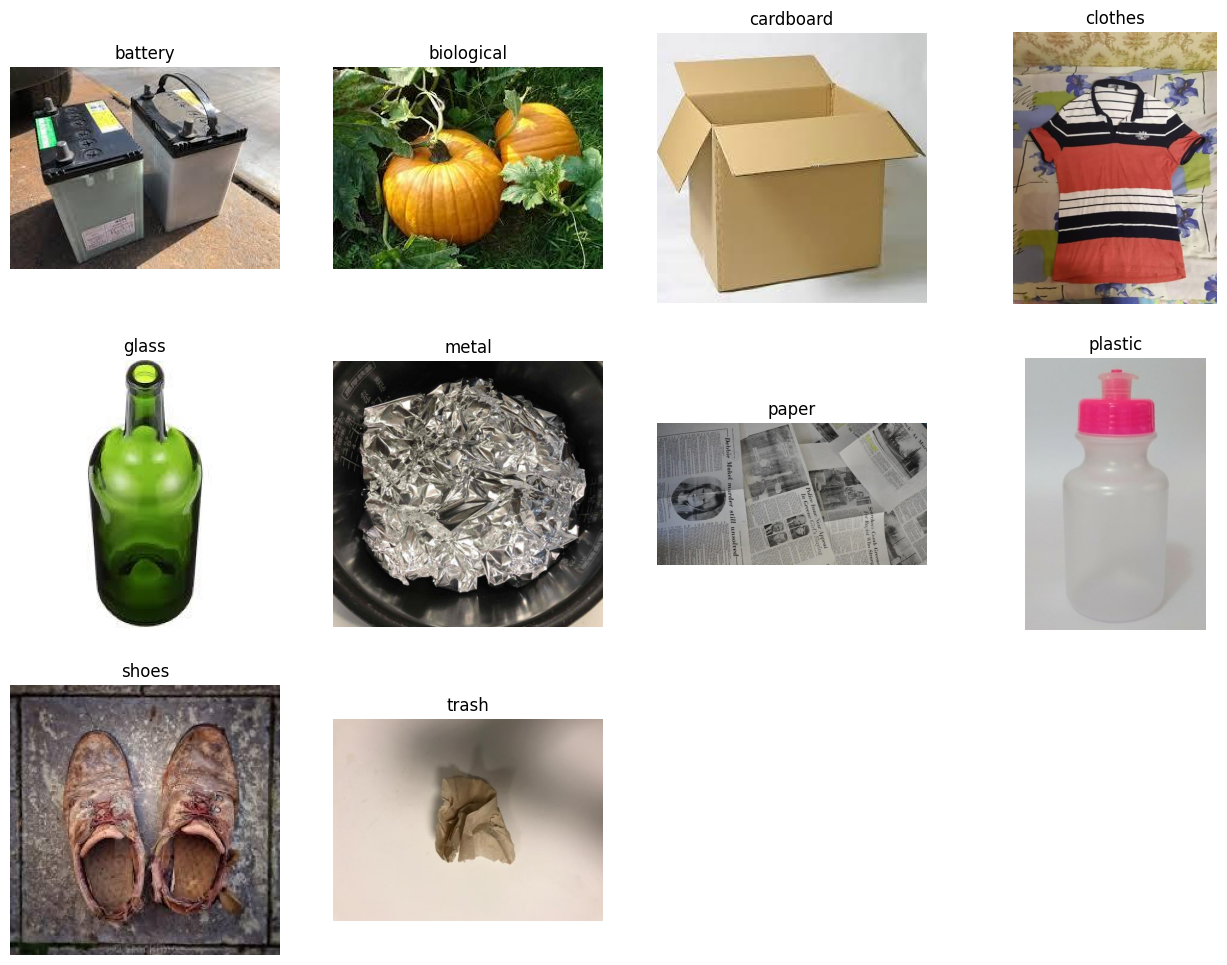

Min width: 51 Max width: 7786
Min height: 71 Max height: 6283


In [8]:
labels = [d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d))]
print("Dataset classes:", labels)

for label in labels:
    folder = os.path.join(BASE_DIR, label)
    print(f"{label}: {len(os.listdir(folder))} images")

cols = 4
rows = math.ceil(len(labels)/cols)
plt.figure(figsize=(4*cols,4*rows))
for i, label in enumerate(labels):
    folder = os.path.join(BASE_DIR, label)
    img_name = random.choice(os.listdir(folder))
    img = Image.open(os.path.join(folder, img_name))
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
plt.show()

all_shapes = []
for label in labels:
    folder = os.path.join(BASE_DIR, label)
    for img_file in os.listdir(folder):
        img = Image.open(os.path.join(folder, img_file))
        all_shapes.append(img.size)
all_shapes = np.array(all_shapes)
print("Min width:", all_shapes[:,0].min(), "Max width:", all_shapes[:,0].max())
print("Min height:", all_shapes[:,1].min(), "Max height:", all_shapes[:,1].max())

# 3. Resize Images

In [9]:
os.makedirs(RESIZED_DIR, exist_ok=True)
for label in labels:
    src_folder = os.path.join(BASE_DIR, label)
    dst_folder = os.path.join(RESIZED_DIR, label)
    os.makedirs(dst_folder, exist_ok=True)
    for img_file in os.listdir(src_folder):
        img = Image.open(os.path.join(src_folder, img_file)).convert("RGB")
        img = img.resize(INPUT_SIZE, Image.LANCZOS)
        img.save(os.path.join(dst_folder, img_file))

# 4. Split Train/Validation

In [10]:
for label in labels:
    images = os.listdir(os.path.join(RESIZED_DIR, label))
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)
    for img in train_imgs:
        os.makedirs(os.path.join(TRAIN_DIR, label), exist_ok=True)
        shutil.copy(os.path.join(RESIZED_DIR, label, img), os.path.join(TRAIN_DIR, label, img))
    for img in val_imgs:
        os.makedirs(os.path.join(VAL_DIR, label), exist_ok=True)
        shutil.copy(os.path.join(RESIZED_DIR, label, img), os.path.join(VAL_DIR, label, img))

# 5. Data Transformations & Datasets

In [11]:
train_transforms = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=train_transforms)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training images: {len(train_dataset)} | Validation images: {len(val_dataset)}")

Training images: 15806 | Validation images: 3956


# 6. Model, Loss & Optimizer

In [12]:
num_classes = len(train_dataset.classes)
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(DEVICE)

# Class weights
class_counts = Counter(train_dataset.targets)
base_weights = {i: 1.0 / class_counts[i] for i in range(len(class_counts))}
multipliers = {"glass":3.0, "metal":2.0, "paper":2.5, "cardboard":1.8, 
               "plastic":1.2, "trash":1.2, "biological":1.1, "shoes":1.1}
weights = [base_weights[i] * multipliers.get(cname,1.0) for cname,i in train_dataset.class_to_idx.items()]
class_weights = torch.FloatTensor(weights).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 7. Training / Validation Functions

In [13]:
history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for i, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        # Print progress per 10 batches
        if i % 100 == 0:
            print(f"Batch [{i}/{len(loader)}], Loss: {loss.item():.4f}")
    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs,1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct/total, all_preds, all_labels

# 8. Train Loop

In [14]:
for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*30}\nEpoch {epoch+1}/{NUM_EPOCHS}\n{'='*30}")
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, DEVICE)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")


Epoch 1/10
Batch [0/494], Loss: 2.4272
Batch [100/494], Loss: 0.9933
Batch [200/494], Loss: 0.7500
Batch [300/494], Loss: 0.8520
Batch [400/494], Loss: 1.1641
Train Loss: 1.0213 | Val Loss: 1.1167 | Val Acc: 67.14%

Epoch 2/10
Batch [0/494], Loss: 0.5794
Batch [100/494], Loss: 0.2805
Batch [200/494], Loss: 0.7019
Batch [300/494], Loss: 0.6604
Batch [400/494], Loss: 0.6288
Train Loss: 0.6929 | Val Loss: 0.8080 | Val Acc: 73.51%

Epoch 3/10
Batch [0/494], Loss: 0.2709
Batch [100/494], Loss: 0.6582
Batch [200/494], Loss: 0.4965
Batch [300/494], Loss: 0.3339
Batch [400/494], Loss: 1.2041
Train Loss: 0.5889 | Val Loss: 0.6085 | Val Acc: 79.88%

Epoch 4/10
Batch [0/494], Loss: 0.8589
Batch [100/494], Loss: 0.3123
Batch [200/494], Loss: 0.3054
Batch [300/494], Loss: 0.3994
Batch [400/494], Loss: 0.4647
Train Loss: 0.4905 | Val Loss: 0.6756 | Val Acc: 78.24%

Epoch 5/10
Batch [0/494], Loss: 0.2190
Batch [100/494], Loss: 0.8601
Batch [200/494], Loss: 0.2619
Batch [300/494], Loss: 0.2379
Batch 

# 9. Plot Loss & Accuracy

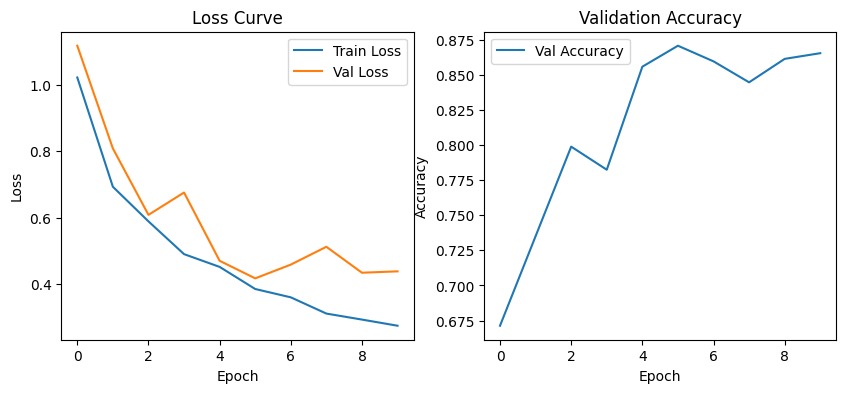

In [15]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1,2,2)
plt.plot(history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Validation Accuracy')
plt.show()

# 10. Evaluation – Classification Report & Confusion Matrix


Classification Report:
              precision    recall  f1-score   support

     battery       0.93      0.86      0.89       189
  biological       0.79      0.93      0.85       200
   cardboard       0.92      0.89      0.91       365
     clothes       0.99      0.83      0.91      1066
       glass       0.81      0.91      0.86       613
       metal       0.79      0.72      0.75       204
       paper       0.75      0.91      0.82       336
     plastic       0.90      0.81      0.85       397
       shoes       0.88      0.89      0.89       396
       trash       0.69      0.91      0.78       190

    accuracy                           0.87      3956
   macro avg       0.84      0.87      0.85      3956
weighted avg       0.88      0.87      0.87      3956



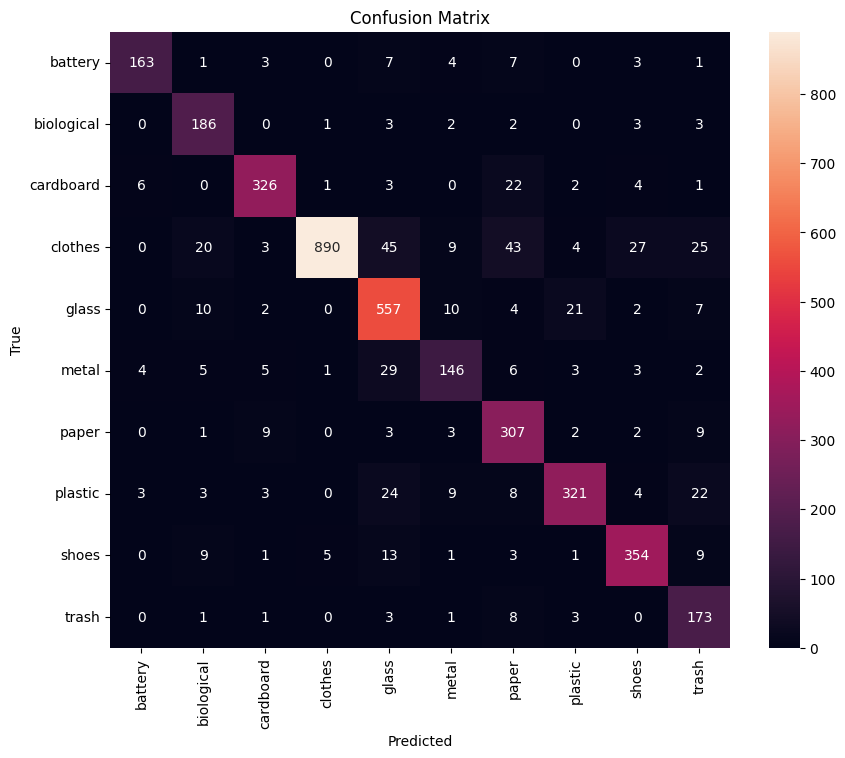

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\nClassification Report:")
print(classification_report(val_labels, val_preds, target_names=train_dataset.classes))

cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# 11. Save Model

In [19]:
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to models/trash_model.pth
